# GATE

GATE is group average treatment effect

# Data

We will use DGP from Causalis. Read more at https://causalis.causalcraft.com/articles/generate_obs_hte_26_rich

In [1]:
from causalis.scenarios.unconfoundedness.dgp import generate_obs_hte_26_rich

data = generate_obs_hte_26_rich(return_causal_data=False, include_oracle=True)
data.head()

,y,d,tenure_months,avg_sessions_week,spend_last_month,age_years,income_monthly,prior_purchases_12m,support_tickets_90d,premium_user,mobile_user,urban_resident,referred_user,m,m_obs,tau_link,g0,g1,cate
0,0.000000,0.0,28.814654,1.0,77.936767,50.234101,1926.698301,1.0,2.0,1.0,1.0,1.0,0.0,0.045453,0.045453,0.089095,8.137981,9.142395,1.004414
1,80.099611,1.0,25.913345,3.0,53.777740,28.115859,5104.271509,3.0,0.0,1.0,1.0,0.0,1.0,0.041514,0.041514,0.246679,60.459257,78.817307,18.358049
2,6.400482,1.0,24.969929,10.0,134.764322,22.907062,5267.938255,8.0,3.0,0.0,1.0,1.0,0.0,0.052593,0.052593,0.162968,7.712855,9.138577,1.425723
3,2.788238,0.0,40.655089,5.0,59.517074,31.970490,6597.327018,3.0,2.0,1.0,1.0,1.0,0.0,0.036221,0.036221,0.188755,25.386510,31.159932,5.773422
4,0.000000,0.0,18.560899,3.0,74.370930,39.237248,4930.009628,5.0,1.0,1.0,1.0,0.0,0.0,0.036343,0.036343,0.174757,15.359250,18.600227,3.240977


In [2]:
print(f"Ground truth ATE is {data['cate'].mean()}")
print(f"Ground truth ATTE is {data[data['d'] == 1]['cate'].mean()}")

Ground truth ATE is 19.409586529660793
Ground truth ATTE is 10.914991423363865


In [3]:
from causalis.data_contracts import CausalData

causaldata = CausalData(df = data,
                        treatment='d',
                        outcome='y',
                        confounders=['tenure_months',
                                     'avg_sessions_week',
                                     'spend_last_month',
                                     'age_years',
                                     'income_monthly',
                                     'prior_purchases_12m',
                                     'support_tickets_90d',
                                     'premium_user',
                                     'mobile_user',
                                     'urban_resident',
                                     'referred_user'])
causaldata

CausalData(df=(100000, 13), treatment='d', outcome='y', confounders=['tenure_months', 'avg_sessions_week', 'spend_last_month', 'age_years', 'income_monthly', 'prior_purchases_12m', 'support_tickets_90d', 'premium_user', 'mobile_user', 'urban_resident', 'referred_user'])

In [4]:
from causalis.shared import outcome_stats
outcome_stats(causaldata)

,treatment,count,mean,std,min,p10,p25,median,p75,p90,max
0,0.0,95051,76.087138,240.800713,0.0,0.0,0.0,8.39544,64.859278,190.227900,21396.007575
1,1.0,4949,58.506172,199.485625,0.0,0.0,0.0,0.00000,36.958280,148.837193,5143.642132


Our data has strong treatment class disbalance. Only 5% of sample activated in treatment.

Treatment group has lower mean LTV. It's too early to draw conclusions.

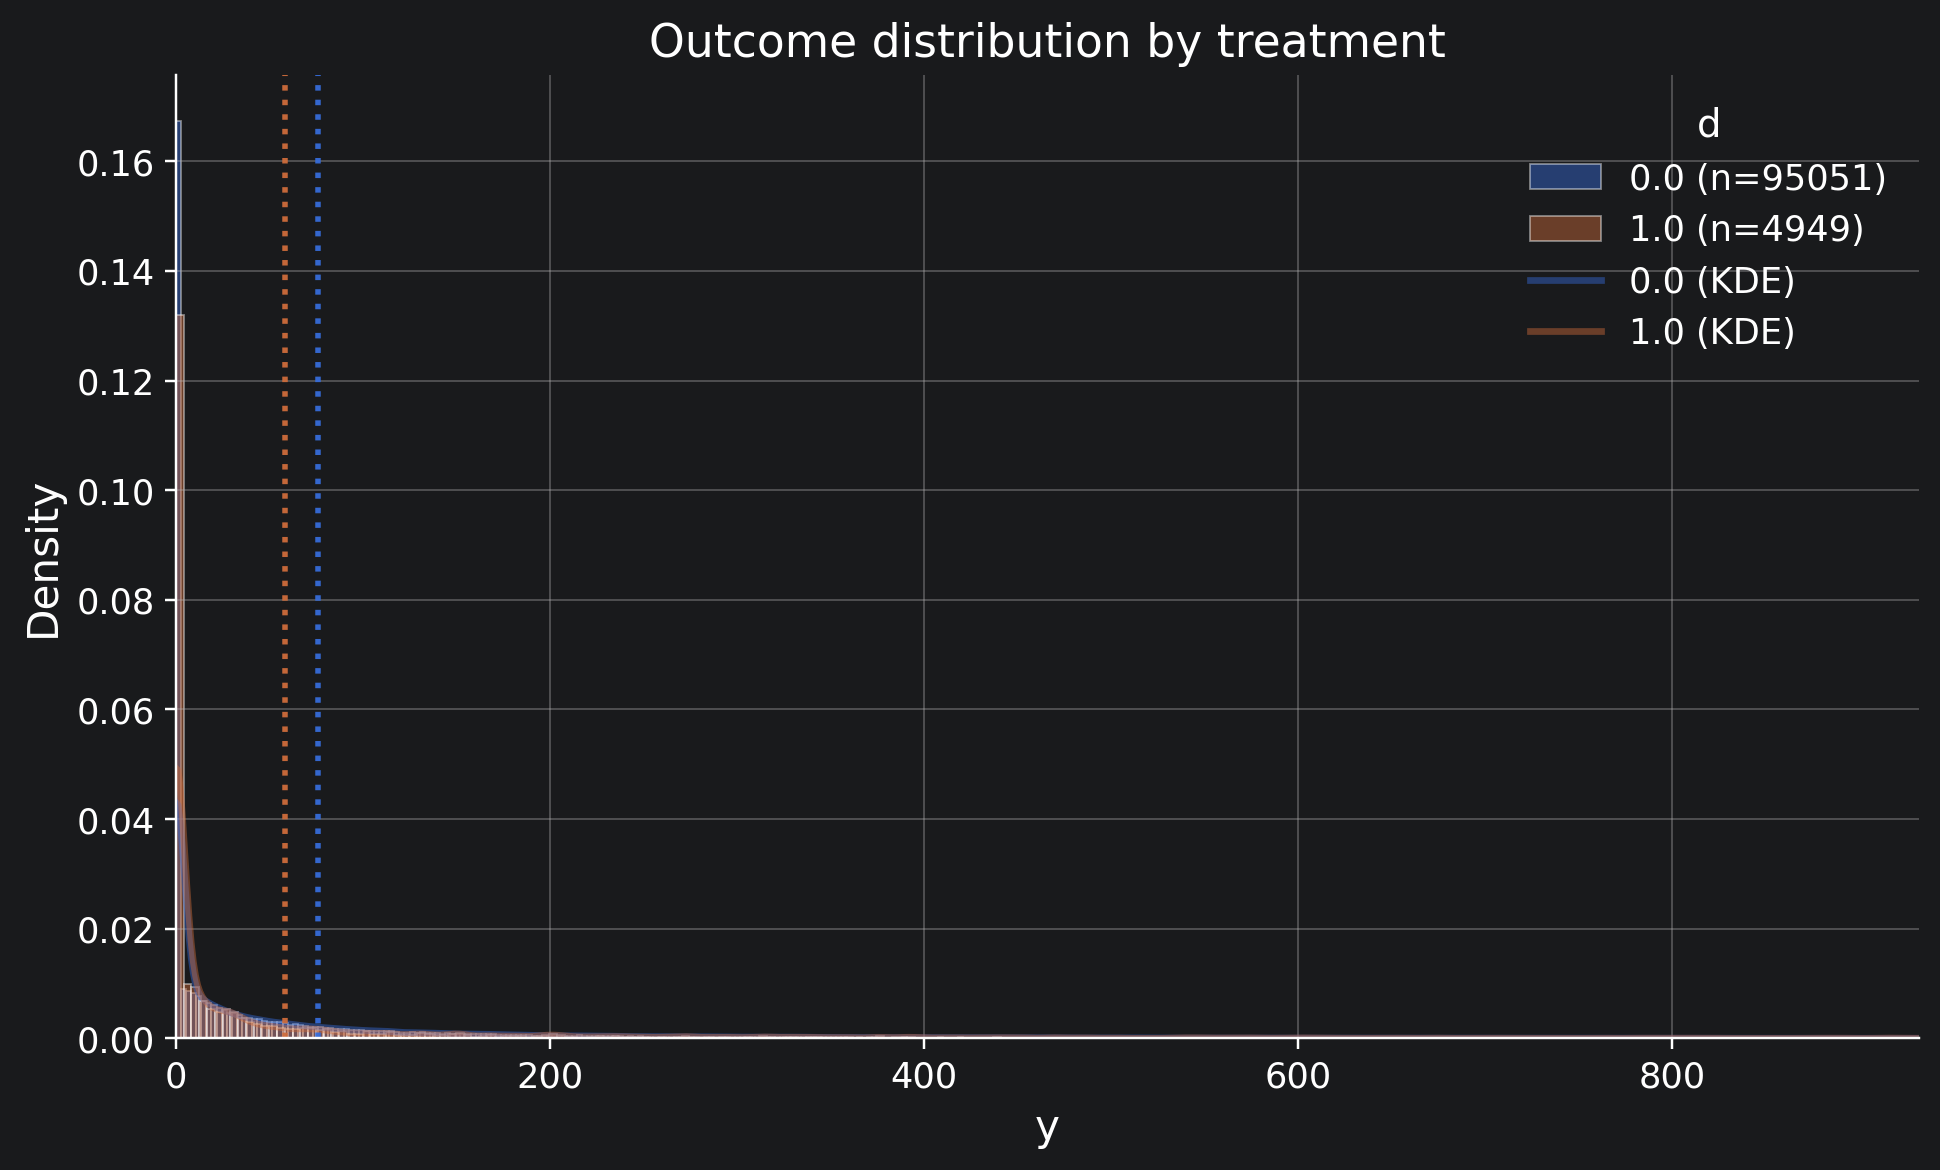

In [5]:
from causalis.shared.outcome_plots import outcome_plot_dist
outcome_plot_dist(causaldata)

We see large right tale

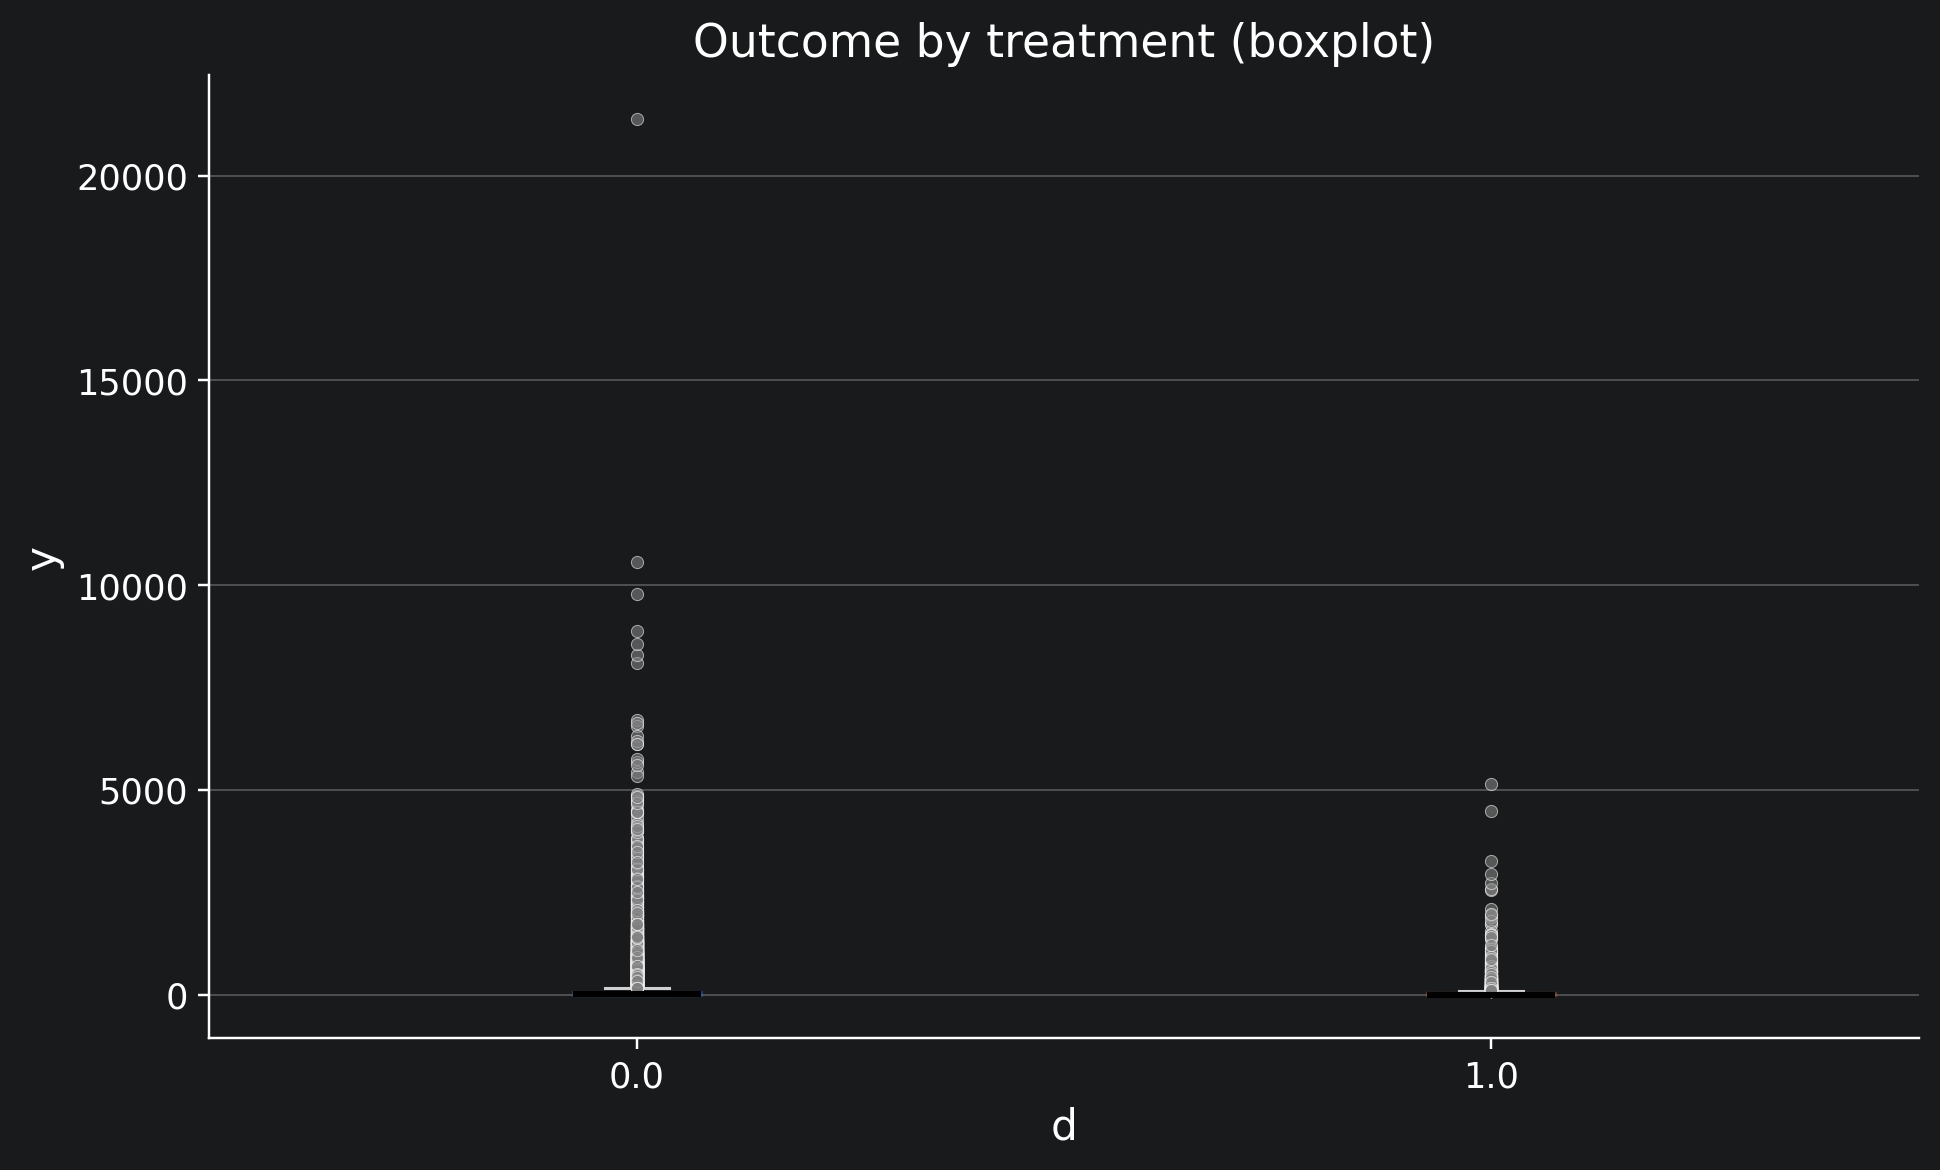

In [6]:
from causalis.shared.outcome_plots import outcome_plot_boxplot
outcome_plot_boxplot(causaldata)

In [7]:
from causalis.shared import outcome_outliers

outcome_outliers(causaldata)

,treatment,n,outlier_count,outlier_rate,lower_bound,upper_bound,has_outliers,method,tail
0,0.0,95051,11300,0.118884,-97.288916,162.148194,True,iqr,both
1,1.0,4949,721,0.145686,-55.437420,92.395699,True,iqr,both


We see many outliers. It's common situation for LTV metric. Dropping them will lead to a biased conclusion

In [8]:
from causalis.shared import confounders_balance

confounders_balance(causaldata)

,confounders,mean_d_0,mean_d_1,abs_diff,smd,ks_pvalue
0,premium_user,0.751807,0.591837,0.159970,-0.345721,0.00000
1,income_monthly,4549.385190,3918.058798,631.326392,-0.277611,0.00000
2,spend_last_month,89.091801,67.375389,21.716412,-0.268360,0.00000
3,support_tickets_90d,0.984545,1.259244,0.274699,0.253974,0.00000
4,avg_sessions_week,5.047753,4.230148,0.817606,-0.201735,0.00000
5,prior_purchases_12m,3.904220,3.513639,0.390581,-0.189372,0.00000
6,tenure_months,28.740100,25.559161,3.180939,-0.184156,0.00000
7,age_years,36.435984,34.809083,1.626901,-0.144142,0.00000
8,referred_user,0.271486,0.307133,0.035647,0.078671,0.00001
9,urban_resident,0.600793,0.568802,0.031991,-0.064954,0.00013


As we see clients are differ on this confounders. We need to controll them to make causal inference

# Inference

ATTE is right estimand here. We will estimate effect on clients that were treated, had first purchase in our product

In [9]:
from causalis.scenarios.unconfoundedness import IRM

model = IRM(n_jobs=-1).fit(causaldata)

In [10]:
dml_result = model.estimate(score='ATTE')
dml_result.summary()

,value
field,
estimand,ATTE
model,IRM
value,"12.9151 (ci_abs: 8.3585, 17.4717)"
value_relative,"28.3281 (ci_rel: 18.1126, 38.5437)"
alpha,0.0500
p_value,0.0000
is_significant,True
n_treated,4949
n_control,95051


Our estimate is 12.1542 dollars (ci_abs: 7.7933, 16.5152). Mean in treatment group is 58.5062 dollars, so without our product it would be 46.3520 dollars.

## GATE

In [11]:
import pandas as pd

groups = pd.qcut(data["prior_purchases_12m"], q=5, duplicates="drop")
model.estimate(score="GATE", groups=groups).summary()

,value,std_error,wald_stat,test_stat,p_value,ci_lower,ci_upper,n_group,n_treated,n_control,share_treated,mean_phi,std_phi,mean_propensity,min_propensity,max_propensity
group,,,,,,,,,,,,,,,,
"prior_purchases_12m=(-0.001, 2.0]",5.397990,5.694226,0.947976,0.947976,0.343142,-5.762488,16.558468,27484,1700,25784,0.061854,5.397990,943.988642,0.060136,0.01,0.817306
"prior_purchases_12m=(2.0, 3.0]",16.687654,8.560950,1.949276,1.949276,0.051262,-0.091499,33.466808,19182,984,18198,0.051298,16.687654,1185.652911,0.050401,0.01,0.562422
"prior_purchases_12m=(3.0, 4.0]",0.778671,9.643710,0.080744,0.080744,0.935646,-18.122654,19.679997,18236,847,17389,0.046447,0.778671,1302.258040,0.045485,0.01,0.499280
"prior_purchases_12m=(4.0, 6.0]",26.977721,11.094991,2.431523,2.431523,0.015036,5.231938,48.723504,23812,1014,22798,0.042584,26.977721,1712.047372,0.041671,0.01,0.486359
"prior_purchases_12m=(6.0, 16.0]",60.840420,42.157218,1.443179,1.443179,0.148970,-21.786209,143.467049,11286,404,10882,0.035797,60.840420,4478.398397,0.034107,0.01,0.595811


In [12]:
model.estimate(score='GATE', groups=data['mobile_user']).summary()

,value,std_error,wald_stat,test_stat,p_value,ci_lower,ci_upper,n_group,n_treated,n_control,share_treated,mean_phi,std_phi,mean_propensity,min_propensity,max_propensity
group,,,,,,,,,,,,,,,,
mobile_user=0.0,5.215562,7.957909,0.655393,0.655393,0.512214,-10.381654,20.812777,12565,643,11922,0.051174,5.215562,891.996087,0.048860,0.01,0.595811
mobile_user=1.0,19.971016,6.943213,2.876336,2.876336,0.004023,6.362569,33.579462,87435,4306,83129,0.049248,19.971016,2053.055286,0.048176,0.01,0.817306
